In [1]:
# ==== Cell 1: Environment ====
!pip install --no-cache-dir --quiet \
  "numpy==1.26.4" \
  "opencv-python-headless==4.10.0.84" \
  "mediapipe==0.10.14" \
  "tensorflow==2.18.0" \
  "protobuf==4.25.3" \
  "scipy==1.11.4"

import os, sys, json, glob, math, time
import numpy as np
import cv2
import tensorflow as tf

print("✅ Ready.")
print("Python:", sys.version)
print("NumPy:", np.__version__, "| TF:", tf.__version__, "| OpenCV:", cv2.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 293.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 210.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 211.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 288.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 261.4 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.3 which is incompatible.

... [9 li

✅ Ready.
Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy: 1.26.4 | TF: 2.18.0 | OpenCV: 4.10.0


In [2]:
# ==== Cell 2: Safe Mediapipe import (Py 3.11) ====
import types

# Patch nhẹ để Mediapipe không lôi 'tasks.audio' (hay lỗi 'framework/python/gpu')
import sys as _sys
_sys.modules.setdefault("mediapipe.tasks", types.SimpleNamespace(python=types.SimpleNamespace(audio=types.SimpleNamespace())))
_sys.modules.setdefault("mediapipe.tasks.python", types.SimpleNamespace(audio=types.SimpleNamespace()))
_sys.modules.setdefault("mediapipe.tasks.python.audio", types.SimpleNamespace())

# Import
import mediapipe as mp
mp_holistic = mp.solutions.holistic
mp_drawing  = mp.solutions.drawing_utils

print("✅ Mediapipe OK:", mp.__version__)


✅ Mediapipe OK: 0.10.14


In [3]:
import mediapipe as mp
import google.protobuf
print(mp.__version__)           # nên >=0.10.21
print(google.protobuf.__version__)  # 4.25.8


0.10.14
4.25.3


In [4]:
# ==== Cell 3: Paths & labels (REPLACE) ====
import os, json, glob
 #tạo thư mục làm việc
BASE_DIR   = "/kaggle/working"
SAVE_DIR   = os.path.join(BASE_DIR, "sign_language_detection")
PRED_DIR   = os.path.join(BASE_DIR, "pred_videos")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

#  Dùng đúng dataset 
DATA_DIR = "/kaggle/input/dataset/SignLanguageVideo_VipCut"
assert os.path.isdir(DATA_DIR), f" Không thấy DATA_DIR: {DATA_DIR}"

# Khóa thứ tự nhãn theo TÊN THƯ MỤC
actions = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
assert len(actions) >= 2, " Cần >=2 thư mục nhãn con trong DATA_DIR"
with open(os.path.join(SAVE_DIR, "labels.json"), "w", encoding="utf-8") as f:
    json.dump(actions, f, ensure_ascii=False, indent=2)

print("DATA_DIR:", DATA_DIR)
print(" LABELS (đã khóa):", actions)

# (tuỳ chọn) In thống kê nhanh mỗi lớp
counts = {lbl: len(glob.glob(os.path.join(DATA_DIR, lbl, "*.mp4"))) for lbl in actions}
print("📊 Per-class counts:", counts, "| Tổng:", sum(counts.values()))


DATA_DIR: /kaggle/input/dataset/SignLanguageVideo_VipCut
 LABELS (đã khóa): ['Again', 'BathRoom', 'Finish', 'Hello', 'Help', 'No', 'Please', 'SeeYouLater', 'ThankYou', 'Yes']
📊 Per-class counts: {'Again': 90, 'BathRoom': 93, 'Finish': 90, 'Hello': 92, 'Help': 90, 'No': 90, 'Please': 90, 'SeeYouLater': 90, 'ThankYou': 90, 'Yes': 90} | Tổng: 905


In [5]:
# ==== Tạo danh sách video + label ====
samples = []
for label in actions:
    vids = glob.glob(os.path.join(DATA_DIR, label, "*.mp4"))
    samples += [(v, label) for v in vids]

print("Total videos:", len(samples))


Total videos: 905


In [6]:
# =========================
# Hàm trích 134 keypoints (UpperBody + Hands rút gọn)
# =========================
import numpy as np

def extract_keypoints_from_frame(results):
    """
    Trích xuất keypoints rút gọn:
    - UpperBody: 4 điểm (11,12,23,24) x 2 (x,y) = 8
    - Hands: left + right hand = 21*3 + 21*3 = 126
    Tổng = 8 + 126 = 134
    """
    # UpperBody
    upperbody_idx = [11, 12, 23, 24]  # Pose landmarks
    upperbody = np.zeros((4,2), dtype=np.float32)
    if results.pose_landmarks:
        for i, idx in enumerate(upperbody_idx):
            lm = results.pose_landmarks.landmark[idx]
            upperbody[i] = [lm.x, lm.y]

    # Hands
    lh = np.zeros((21,3), dtype=np.float32)
    rh = np.zeros((21,3), dtype=np.float32)
    if results.left_hand_landmarks:
        for i, lm in enumerate(results.left_hand_landmarks.landmark):
            lh[i] = [lm.x, lm.y, lm.z]
    if results.right_hand_landmarks:
        for i, lm in enumerate(results.right_hand_landmarks.landmark):
            rh[i] = [lm.x, lm.y, lm.z]

    return np.concatenate([upperbody.flatten(), lh.flatten(), rh.flatten()])

In [7]:
# ==== Cell 4: Keypoint extraction & video reading ====
import numpy as np
import cv2

SEQLEN = 48
RAW_FEAT_DIM = 134  # UpperBody + Hands rút gọn

def read_video_keypoints(vpath, seqlen=SEQLEN, step=1, head_sec=0.0, tail_sec=0.0):
    """
    Đọc video, trích xuất keypoints 134 chiều và trả về sliding windows (N, SEQLEN, RAW_FEAT_DIM)
    """
    from mediapipe import solutions as mp_solutions

    cap = cv2.VideoCapture(vpath)
    if not cap.isOpened():
        print("Cannot open:", vpath)
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    start_f = int(round(fps * head_sec))
    end_f   = total - int(round(fps * tail_sec)) if total > 0 else 10**9

    if start_f > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)

    frames = []
    with mp_solutions.holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False
    ) as hol:
        idx = start_f
        while True:
            ok, frame = cap.read()
            if not ok or idx >= end_f:
                break
            idx += 1
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = hol.process(frame)
            frames.append(extract_keypoints_from_frame(res))

    cap.release()
    arr = np.array(frames, dtype=np.float32)
    if len(arr) < seqlen:
        return []

    seqs = []
    for i in range(0, len(arr) - seqlen + 1, step):
        seqs.append(arr[i:i+seqlen])
    return seqs


In [8]:
# ==== Cell 4b: Build dataset ====
import os, glob
import numpy as np
import tensorflow as tf
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SEQLEN = 48
RAW_FEAT_DIM = 134

def sequence_upperbody_hand_normalize(seq):
    """
    Chuẩn hóa: dịch chuyển trung tâm và scale dựa trên vai/hips.
    seq: (SEQLEN, RAW_FEAT_DIM)
    """
    s = seq.copy()
    # UpperBody: 4 điểm x 2 (x,y)
    upper = s[:, :8]

    # Hands: 21*3 x2 = 126
    lh = s[:, 8:8+63].reshape(-1,21,3)
    rh = s[:, 8+63:].reshape(-1,21,3)

    # Tính trung tâm vai/hips (dùng UpperBody)
    ls = upper[:,0:2]   # 11
    rs = upper[:,2:4]   # 12
    lh_c = upper[:,4:6] # 23
    rh_c = upper[:,6:8] # 24
    shoulders = (ls+rs)/2
    hips      = (lh_c+rh_c)/2
    center = (shoulders+hips)/2
    scale = np.linalg.norm(shoulders-hips, axis=1, keepdims=True) + 1e-6

    # Chuẩn hóa hand
    lh[:,:,0:2] = (lh[:,:,0:2] - center[:,None,:])/scale[:,None,:]
    rh[:,:,0:2] = (rh[:,:,0:2] - center[:,None,:])/scale[:,None,:]

    lh_out = lh.reshape(-1,63)
    rh_out = rh.reshape(-1,63)

    return np.concatenate([upper, lh_out, rh_out], axis=1).astype(np.float32)


def process_single_video(vpath, label, stride, actions):
    seqs = read_video_keypoints(vpath, seqlen=SEQLEN, step=stride, head_sec=0.3)
    seqs = [sequence_upperbody_hand_normalize(s) for s in seqs]

    X_v, y_v = [], []
    onehot = tf.keras.utils.to_categorical(actions.index(label), num_classes=len(actions))
    for s in seqs:
        if s.shape == (SEQLEN, RAW_FEAT_DIM):
            X_v.append(s)
            y_v.append(onehot)
    return X_v, y_v, {label: len(X_v)}


def build_split_parallel(samples, stride=8, max_workers=8):
    X_list, y_list, counts = [], [], {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(process_single_video, v, l, stride, actions):(v,l) for v,l in samples}
        for fut in tqdm(as_completed(futs), total=len(futs)):
            X_v, y_v, c = fut.result()
            X_list += X_v
            y_list += y_v
            for k,v in c.items():
                counts[k] = counts.get(k,0) + v
    return np.array(X_list), np.array(y_list), counts


# ===== Prepare samples =====
samples = []
for label in actions:
    vids = glob.glob(os.path.join(DATA_DIR, label, "*.mp4"))
    for v in vids:
        samples.append((v,label))

train_samples, val_samples = train_test_split(samples, test_size=0.2, random_state=42)

stride = 8
X_train, y_train, counts_train = build_split_parallel(train_samples, stride=stride)
X_val, y_val, counts_val = build_split_parallel(val_samples, stride=stride)

print("✅ X_train:", X_train.shape, "| y_train:", y_train.shape)
print("✅ X_val:", X_val.shape, "| y_val:", y_val.shape)
print("📊 Train counts:", counts_train)
print("📊 Val counts:", counts_val)
print("Raw feature dim:", RAW_FEAT_DIM, "| Seq len:", SEQLEN)


✅ X_train: (4414, 48, 134) | y_train: (4414, 10)
✅ X_val: (1089, 48, 134) | y_val: (1089, 10)
📊 Train counts: {'Again': 531, 'ThankYou': 411, 'Help': 328, 'Hello': 352, 'SeeYouLater': 512, 'Yes': 536, 'BathRoom': 594, 'Finish': 347, 'Please': 362, 'No': 441}
📊 Val counts: {'Again': 120, 'Finish': 97, 'No': 95, 'BathRoom': 95, 'Yes': 162, 'Help': 78, 'SeeYouLater': 75, 'Hello': 147, 'Please': 117, 'ThankYou': 103}
Raw feature dim: 134 | Seq len: 48


In [9]:
# === Cell SPLIT: Tất cả video chứa 'section_' đưa vào validation ===

train_samples = []
val_samples = []

for label in actions:
    folder = os.path.join(DATA_DIR, label)
    vids = sorted(glob.glob(os.path.join(folder, "*.mp4")))

    for v in vids:
        fname = os.path.basename(v).lower()

        # Nếu tên chứa section_XX → cho vào validation
        if "section_" in fname:
            val_samples.append((v, label))
        else:
            train_samples.append((v, label))

# --- Thống kê ---
print("=== VIDEO SPLIT SUMMARY ===")
for label in actions:
    t_count = sum(1 for _, l in train_samples if l == label)
    v_count = sum(1 for _, l in val_samples if l == label)
    print(f"{label:12s} | train={t_count:3d} | val={v_count:3d}")

print("\n➡️ Sẵn sàng build dataset bằng build_split_parallel(...)")


=== VIDEO SPLIT SUMMARY ===
Again        | train= 70 | val= 20
BathRoom     | train= 73 | val= 20
Finish       | train= 70 | val= 20
Hello        | train= 72 | val= 20
Help         | train= 70 | val= 20
No           | train= 70 | val= 20
Please       | train= 70 | val= 20
SeeYouLater  | train= 70 | val= 20
ThankYou     | train= 70 | val= 20
Yes          | train= 70 | val= 20

➡️ Sẵn sàng build dataset bằng build_split_parallel(...)


In [10]:
# ==== Cell Build & Train: 2-layer model ====
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks

seq_len = SEQLEN      # 48
feat_dim = RAW_FEAT_DIM  # 134
num_classes = len(actions)

# --- Positional embedding ---
class LearnedPositionalEmbedding(layers.Layer):
    def __init__(self, max_len, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
    def build(self, input_shape):
        d_model = input_shape[-1]
        self.pos_emb = self.add_weight(
            name="pos_emb", shape=(self.max_len, d_model),
            initializer="uniform", trainable=True
        )
    def call(self, x):
        return x + self.pos_emb
    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len})
        return config

# --- Attention pooling ---
class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(shape=(d,1), initializer="glorot_uniform", trainable=True)
    def call(self, x):
        scores = tf.nn.softmax(tf.squeeze(tf.matmul(x,self.W),axis=-1), axis=1)
        ctx = tf.reduce_sum(x * scores[:,:,None], axis=1)
        return ctx
    def get_config(self):
        return super().get_config()

# --- Build model ---
inputs = layers.Input(shape=(seq_len, feat_dim))
x = layers.GaussianNoise(0.01)(inputs)

# 1 Conv1D layer
x = layers.Conv1D(192, 5, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# 1 BiLSTM layer
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

# Positional embedding
x = LearnedPositionalEmbedding(max_len=seq_len)(x)

# Attention pooling + Dense head
ctx = AttentionPooling()(x)
x = layers.Dense(256, activation="relu")(ctx)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# --- Compile ---
opt = optimizers.AdamW(learning_rate=2e-4, weight_decay=1e-4)
loss_fn = losses.CategoricalCrossentropy(label_smoothing=0.02)
top2 = tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2")
model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy", top2])
model.summary()

# --- Callbacks ---
checkpoint = callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

# --- Train ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, reduce_lr]
)


2025-11-28 11:11:20.769674: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 134)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 48, 134)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 192)        │       128,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 192)        │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ learned_positional_embedding    │ (None
... [truncated] ...

 Total params: 539,210 (2.06 MB)

 Trainable params: 538,826 (2.06 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.6121 - loss: 1.2962 - top2: 0.7956 - val_accuracy: 0.6814 - val_loss: 1.0627 - val_top2: 0.8494 - learning_rate: 2.0000e-04

... [44 epochs omitted] ...

Epoch 49/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 1.0000 - loss: 0.1357 - top2: 1.0000 - val_accuracy: 0.9982 - val_loss: 0.1379 - val_top2: 0.9991 - learning_rate: 1.2500e-05
Epoch 50/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.9999 - loss: 0.1360 - top2: 1.0000 - val_accuracy: 0.9982 - val_loss: 0.1387 - val_top2: 0.9991 - learning_rate: 1.2500e-05


In [11]:
# Lưu model cuối cùng (không chỉ best)
model.save("final_model.keras")


In [12]:
from tensorflow.keras.models import load_model

# --- 1. Định nghĩa lại các custom layers ---
class LearnedPositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
    def build(self, input_shape):
        d_model = input_shape[-1]
        self.pos_emb = self.add_weight(
            name="pos_emb", shape=(self.max_len, d_model),
            initializer="uniform", trainable=True
        )
    def call(self, x):
        return x + self.pos_emb
    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len})
        return config

class AttentionPooling(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(shape=(d,1), initializer="glorot_uniform", trainable=True)
    def call(self, x):
        scores = tf.nn.softmax(tf.squeeze(tf.matmul(x,self.W),axis=-1), axis=1)
        ctx = tf.reduce_sum(x * scores[:,:,None], axis=1)
        return ctx
    def get_config(self):
        return super().get_config()

# --- 2. Load model với custom_objects ---
custom_objs = {
    "LearnedPositionalEmbedding": LearnedPositionalEmbedding,
    "AttentionPooling": AttentionPooling
}

model_path = "/kaggle/working/best_model.keras"  # hoặc .h5
model = load_model(model_path, custom_objects=custom_objs, compile=False)
print("Model loaded!")


Model loaded!


In [13]:
# ==== Cell: Kiểm tra actions ====
print("✅ Actions list (classes):")
for i, act in enumerate(actions):
    print(f"{i:02d} -> {act}")

# Nếu muốn in số lượng video trên train/val cho từng action
print("\n📊 Train counts:")
for k,v in counts_train.items():
    print(f"{k}: {v} sequences")

print("\n📊 Val counts:")
for k,v in counts_val.items():
    print(f"{k}: {v} sequences")


✅ Actions list (classes):
00 -> Again
01 -> BathRoom
02 -> Finish
03 -> Hello
04 -> Help
05 -> No
06 -> Please
07 -> SeeYouLater
08 -> ThankYou

... [18 lines omitted] ...

Help: 78 sequences
SeeYouLater: 75 sequences
Hello: 147 sequences
Please: 117 sequences
ThankYou: 103 sequences


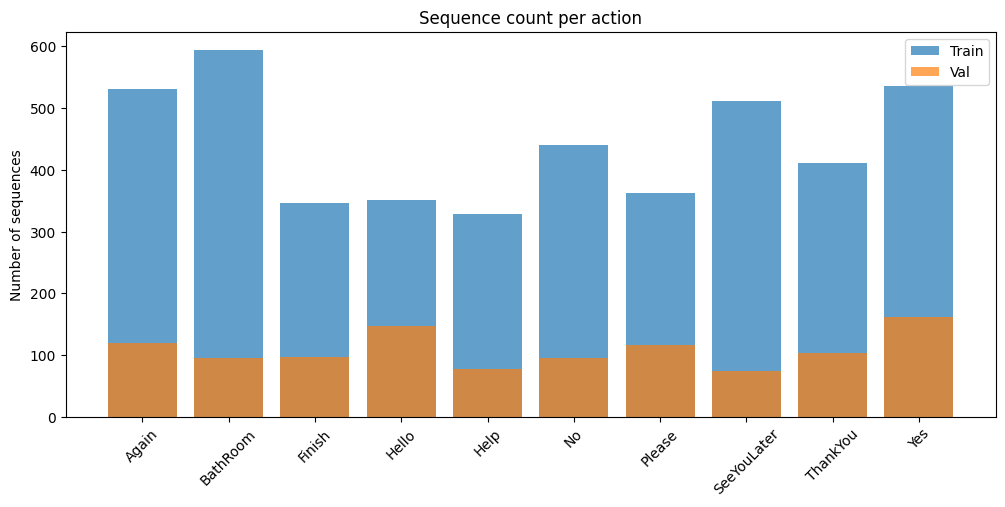

In [14]:
import matplotlib.pyplot as plt

# Sắp xếp theo thứ tự actions
counts_train_sorted = [counts_train[a] for a in actions]
counts_val_sorted   = [counts_val[a] for a in actions]

plt.figure(figsize=(12,5))
plt.bar(actions, counts_train_sorted, alpha=0.7, label="Train")
plt.bar(actions, counts_val_sorted, alpha=0.7, label="Val")
plt.ylabel("Number of sequences")
plt.title("Sequence count per action")
plt.xticks(rotation=45)
plt.legend()
plt.show()


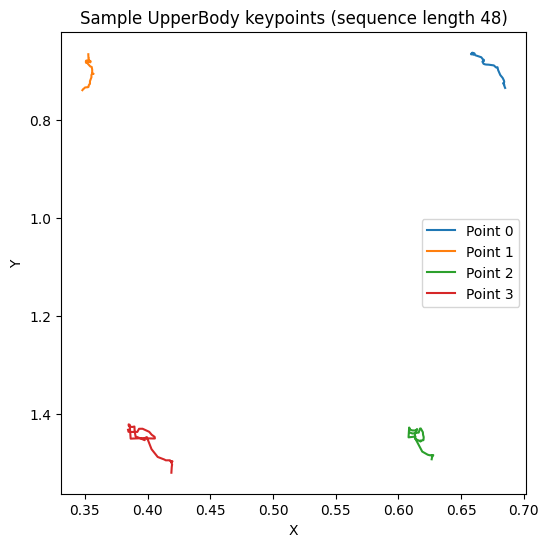

In [15]:
# Lấy 1 sequence train bất kỳ
seq = X_train[0]  # shape: (SEQLEN, 134)

# UpperBody: 4 điểm x 2 (x,y)
upper = seq[:, :8].reshape(SEQLEN, 4, 2)

plt.figure(figsize=(6,6))
for i in range(4):
    plt.plot(upper[:,i,0], upper[:,i,1], label=f'Point {i}')
plt.gca().invert_yaxis()  # y xuống dưới giống OpenCV
plt.title(f"Sample UpperBody keypoints (sequence length {SEQLEN})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


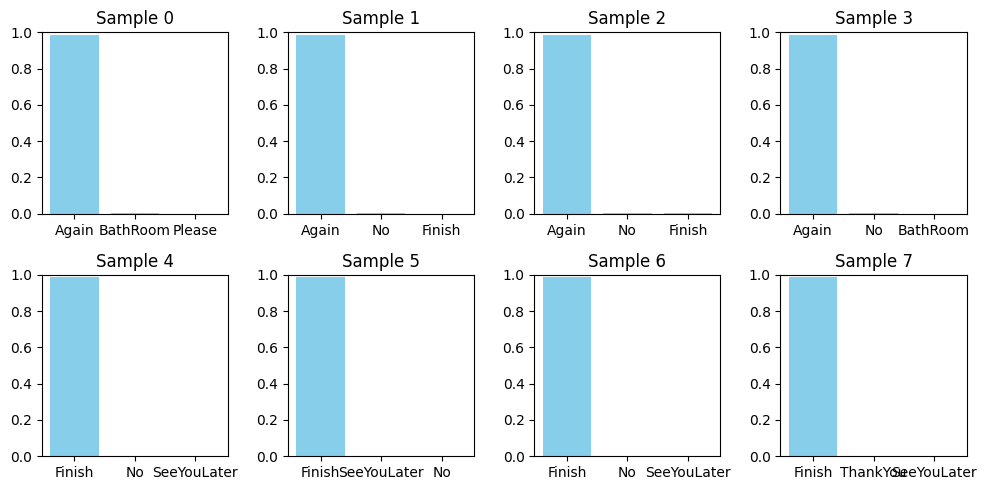

In [16]:
# Lấy 1 batch nhỏ
X_sample = X_val[:8]
y_sample = y_val[:8]

preds = model.predict(X_sample)  # (batch, num_classes)

plt.figure(figsize=(10,5))
for i, p in enumerate(preds):
    top3_idx = p.argsort()[-3:][::-1]
    top3_vals = p[top3_idx]
    top3_labels = [actions[j] for j in top3_idx]
    plt.subplot(2,4,i+1)
    plt.bar(top3_labels, top3_vals, color='skyblue')
    plt.ylim(0,1)
    plt.title(f"Sample {i}")
plt.tight_layout()
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


<Figure size 1000x1000 with 0 Axes>

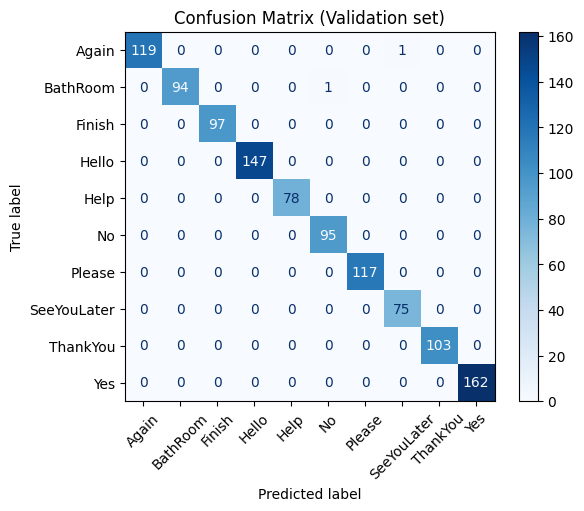

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(X_val, batch_size=32)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=actions)
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (Validation set)")
plt.show()


In [ ]:
# ==== Cell: Test Video + Overlay (Beautiful UI + Skeleton) ====
import cv2
import numpy as np
from mediapipe import solutions as mp_solutions

SEQLEN = 48
RAW_FEAT_DIM = 134

video_path = "/kaggle/input/againtest/21549.mp4"
out_path   = "/kaggle/working/test_output.mp4"

actions = ["Again","BathRoom","Finish","Hello","Help","No","Please","SeeYouLater","ThankYou","Yes"]

# ------------------------ DRAWING UTILS ------------------------
def draw_skeleton(frame, res):
    mp_drawing = mp_solutions.drawing_utils
    mp_style   = mp_solutions.drawing_styles
    mp_pose    = mp_solutions.pose
    mp_hands   = mp_solutions.hands

    # Pose skeleton (neutral cyan + purple)
    if res.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_style.get_default_pose_landmarks_style(),
        )

    # Hand skeleton (custom neon color)
    if res.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.left_hand_landmarks,
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,255), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(0,128,255), thickness=2)
        )

    if res.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.right_hand_landmarks,
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(255,255,0), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(255,128,0), thickness=2)
        )

def draw_fancy_text(frame, text, pos=(30,50), scale=1.5):
    x, y = pos

    # Background box (transparent)
    overlay = frame.copy()
    cv2.rectangle(overlay, (x-10, y-40), (x + 550, y+20), (0,0,0), -1)
    frame[:] = cv2.addWeighted(overlay, 0.4, frame, 0.6, 0)

    # Shadow effect
    cv2.putText(frame, text, (x+3,y+3), cv2.FONT_HERSHEY_SIMPLEX, scale, (0,0,0), 5, cv2.LINE_AA)

    # Main text in strong yellow
    cv2.putText(frame, text, (x,y), cv2.FONT_HERSHEY_SIMPLEX, scale, (0,255,255), 4, cv2.LINE_AA)

# ------------------------ LOAD VIDEO ------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video:", video_path)
    exit()

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_vid = cv2.VideoWriter(out_path, fourcc, fps, (w,h))

frames = []
raw_frames = []

# ------------------------ EXTRACT FRAMES + KEYPOINTS ------------------------
with mp_solutions.holistic.Holistic(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    enable_segmentation=False
) as hol:

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = hol.process(frame_rgb)

        kpts = extract_keypoints_from_frame(res)
        frames.append(kpts)
        raw_frames.append((frame.copy(), res))  # save both frame + mediapipe results

cap.release()
frames = np.array(frames, dtype=np.float32)

# ------------------------ CREATE SEQUENCES ------------------------
seqs = []
frame_indices = []
for i in range(0, len(frames)-SEQLEN+1):
    seq = frames[i:i+SEQLEN]
    seq = sequence_upperbody_hand_normalize(seq)
    seqs.append(seq)
    frame_indices.append(i+SEQLEN-1)

if len(seqs) == 0:
    print("Video quá ngắn (< SEQLEN)!")
    exit()

X_test = np.array(seqs, dtype=np.float32)

# ------------------------ MODEL PREDICT ------------------------
preds = model.predict(X_test, batch_size=8)
pred_classes = np.argmax(preds, axis=1)
pred_actions = [actions[i] for i in pred_classes]

frame_action_map = dict(zip(frame_indices, pred_actions))

# ------------------------ DRAW & WRITE OUTPUT ------------------------
for i, (frame, res) in enumerate(raw_frames):

    # 1) Vẽ skeleton
    draw_skeleton(frame, res)

    # 2) Overlay action label
    if i in frame_action_map:
        action = frame_action_map[i]
        draw_fancy_text(frame, f"Action: {action}", (30,80), scale=1.8)

    out_vid.write(frame)

out_vid.release()
print("🎉 Video output saved to:", out_path)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


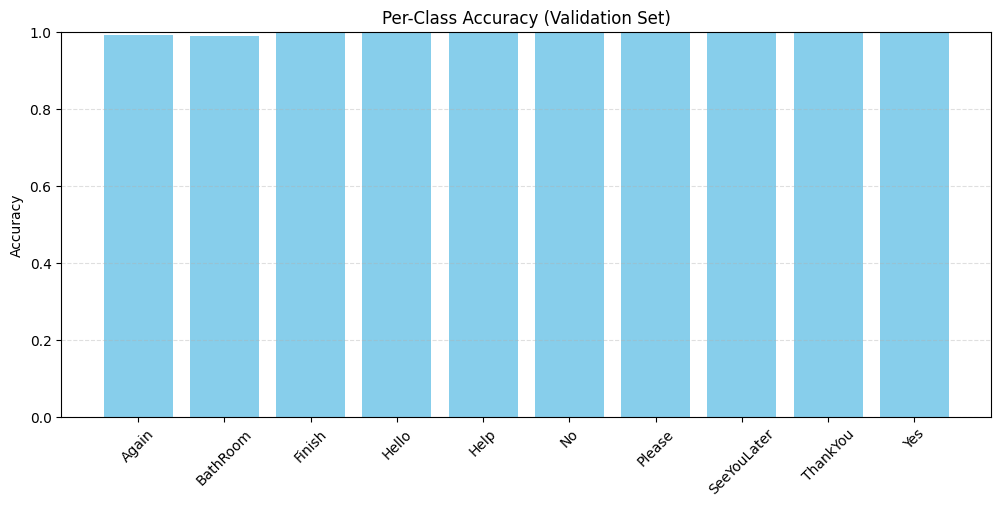

Again       :  99.2%
BathRoom    :  98.9%
Finish      : 100.0%
Hello       : 100.0%
Help        : 100.0%
No          : 100.0%
Please      : 100.0%
SeeYouLater : 100.0%
ThankYou    : 100.0%
Yes         : 100.0%


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ----- 1. Predict -----
preds = model.predict(X_val, batch_size=32)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_val, axis=1)

num_classes = len(actions)
class_acc = []

# ----- 2. Compute per-class accuracy -----
for cls in range(num_classes):
    idx = np.where(y_true == cls)[0]
    if len(idx) == 0:
        class_acc.append(0)
    else:
        acc = np.mean(y_pred[idx] == cls)
        class_acc.append(acc)

# ----- 3. Plot -----
plt.figure(figsize=(12,5))
plt.bar(actions, class_acc, color="skyblue")
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy (Validation Set)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Print in console too
for a, acc in zip(actions, class_acc):
    print(f"{a:12s}: {acc*100:5.1f}%")


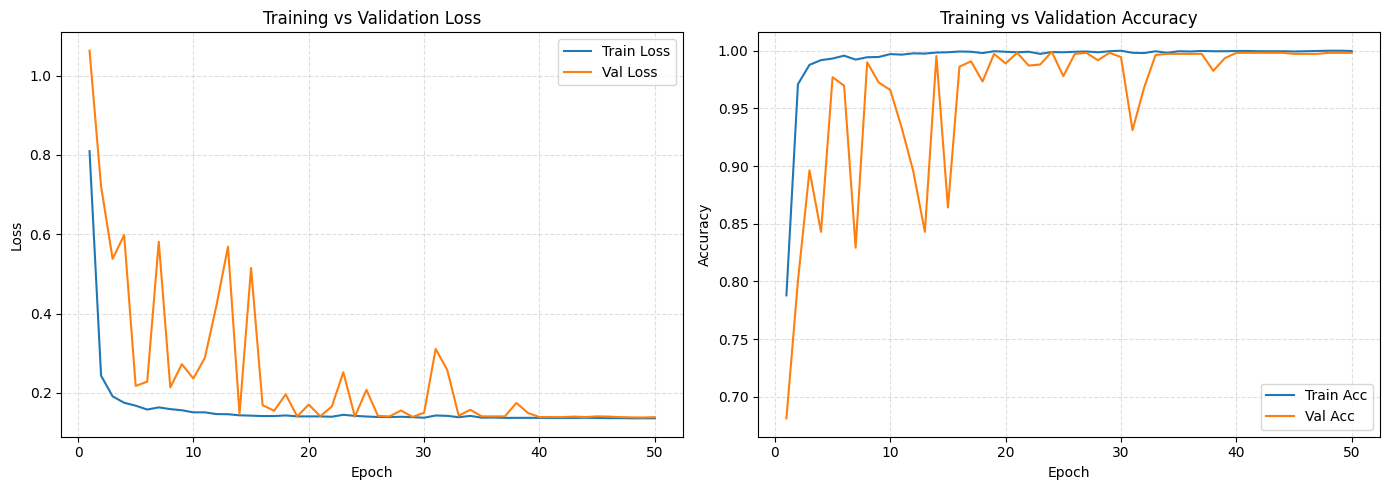

In [21]:
import matplotlib.pyplot as plt

# Lấy biến history
h = history.history

epochs = range(1, len(h["loss"]) + 1)

plt.figure(figsize=(14,5))

# --------- LOSS ----------
plt.subplot(1,2,1)
plt.plot(epochs, h["loss"], label="Train Loss")
plt.plot(epochs, h["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

# --------- ACCURACY ----------
plt.subplot(1,2,2)
plt.plot(epochs, h["accuracy"], label="Train Acc")
plt.plot(epochs, h["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [34]:
# ==== BEAUTIFUL TEST VIDEO CELL (Ultimate UI Edition, Center-only Predict) ====
import cv2
import numpy as np
from mediapipe import solutions as mp_solutions
import math

SEQLEN = 48
RAW_FEAT_DIM = 134

video_path = "/kaggle/input/testthankyou/5211961-uhd_3840_2160_25fps (1).mp4"
out_path   = "/kaggle/working/test_output.mp4"

actions = ["Again","BathRoom","Finish","Hello","Help","No","Please","SeeYouLater","ThankYou","Yes"]

# ------------------------ COLOR UTILS ------------------------
def confidence_to_color(p):
    p = float(p)
    if p < 0.5:
        r = 0
        g = int(255 * (p / 0.5)) 
        b = 255
    else:
        r = 0
        g = 255
        b = int(255 * (1 - (p - 0.5) / 0.5))
    return (b, g, r)

def smooth(prev, new, alpha=0.3):
    if prev is None:
        return new
    return prev * (1 - alpha) + new * alpha

# ------------------------ DRAWING UTILS ------------------------
def draw_skeleton(frame, res):
    mp_drawing = mp_solutions.drawing_utils
    mp_style   = mp_solutions.drawing_styles
    mp_pose    = mp_solutions.pose
    mp_hands   = mp_solutions.hands

    if res.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_style.get_default_pose_landmarks_style(),
        )

    if res.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.left_hand_landmarks,
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,255), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(0,128,255), thickness=2)
        )

    if res.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            res.right_hand_landmarks,
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(255,255,0), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(255,128,0), thickness=2)
        )

def draw_label_box(frame, text, conf, pos=(30,80)):
    x,y = pos
    color = confidence_to_color(conf)

    overlay = frame.copy()
    cv2.rectangle(overlay, (x-15, y-55), (x + 650, y+35), (0,0,0), -1)
    frame[:] = cv2.addWeighted(overlay, 0.35, frame, 0.65, 0)

    cv2.putText(frame, text, (x+4,y+4),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0,0,0), 6, cv2.LINE_AA)

    cv2.putText(frame, text, (x,y),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, color, 5, cv2.LINE_AA)

    bar_x1 = x
    bar_y1 = y + 20
    bar_x2 = x + 500
    bar_y2 = bar_y1 + 20

    cv2.rectangle(frame, (bar_x1, bar_y1), (bar_x2, bar_y2),
                  (40,40,40), -1, cv2.LINE_AA)

    fill_w = int((conf) * 500)
    cv2.rectangle(frame, (bar_x1, bar_y1),
                  (bar_x1 + fill_w, bar_y2),
                  color, -1, cv2.LINE_AA)


# ------------------------ LOAD VIDEO ------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video:", video_path)
    exit()

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_vid = cv2.VideoWriter(out_path, fourcc, fps, (w,h))

frames = []
raw_frames = []

# ------------------------ EXTRACT FRAMES + KEYPOINTS ------------------------
with mp_solutions.holistic.Holistic(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    enable_segmentation=False
) as hol:

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = hol.process(frame_rgb)

        kpts = extract_keypoints_from_frame(res)
        frames.append(kpts)
        raw_frames.append((frame.copy(), res))

cap.release()
frames = np.array(frames, dtype=np.float32)

# ------------------------ CREATE SEQUENCES (only middle 2/3) ------------------------
seqs = []
frame_indices = []

total_f = len(frames)
mid_start = int(total_f * (1/6))      # bỏ 1/6 đầu
mid_end   = int(total_f * (5/6))      # bỏ 1/6 cuối

for i in range(0, len(frames)-SEQLEN+1):
    mid_frame = i + SEQLEN - 1

    # chỉ giữ frame trong khoảng 2/3 giữa video
    if mid_frame < mid_start or mid_frame > mid_end:
        continue

    seq = frames[i:i+SEQLEN]
    seq = sequence_upperbody_hand_normalize(seq)

    seqs.append(seq)
    frame_indices.append(mid_frame)

if len(seqs) == 0:
    print("Không có sequence nào trong phần giữa video.")
    exit()

X_test = np.array(seqs, dtype=np.float32)

# ------------------------ MODEL PREDICT ------------------------
preds = model.predict(X_test, batch_size=8)
pred_classes = np.argmax(preds, axis=1)
pred_probs   = np.max(preds, axis=1)

frame_action_map = dict(zip(frame_indices, pred_classes))
frame_conf_map   = dict(zip(frame_indices, pred_probs))

smooth_conf = None

# ------------------------ DRAW & WRITE OUTPUT ------------------------
for i, (frame, res) in enumerate(raw_frames):

    draw_skeleton(frame, res)

    if i in frame_action_map:
        cls = frame_action_map[i]
        conf = frame_conf_map[i]
        smooth_conf = smooth(smooth_conf, conf)
        label = f"{actions[cls]}  |  {smooth_conf*100:.1f}%"
        draw_label_box(frame, label, smooth_conf, (30,80))

    out_vid.write(frame)

out_vid.release()
print("🎉 Beautiful video saved to:", out_path)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
🎉 Beautiful video saved to: /kaggle/working/test_output.mp4


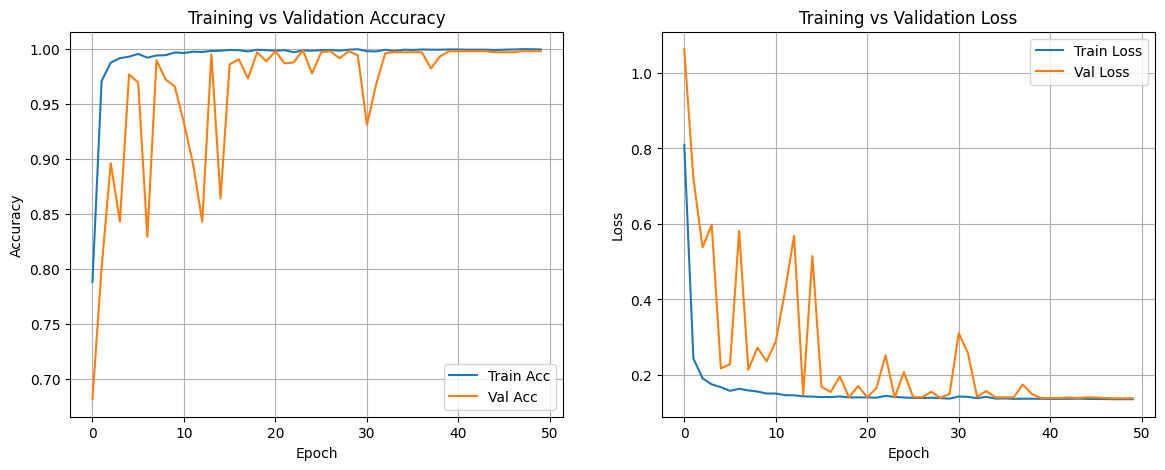

In [25]:
# ==== Cell 1: Plot Accuracy & Loss ====
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(14,5))

# ---- Accuracy ----
ax[0].plot(history.history['accuracy'], label='Train Acc')
ax[0].plot(history.history['val_accuracy'], label='Val Acc')
ax[0].set_title("Training vs Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].grid(True)
ax[0].legend()

# ---- Loss ----
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title("Training vs Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].grid(True)
ax[1].legend()

plt.show()


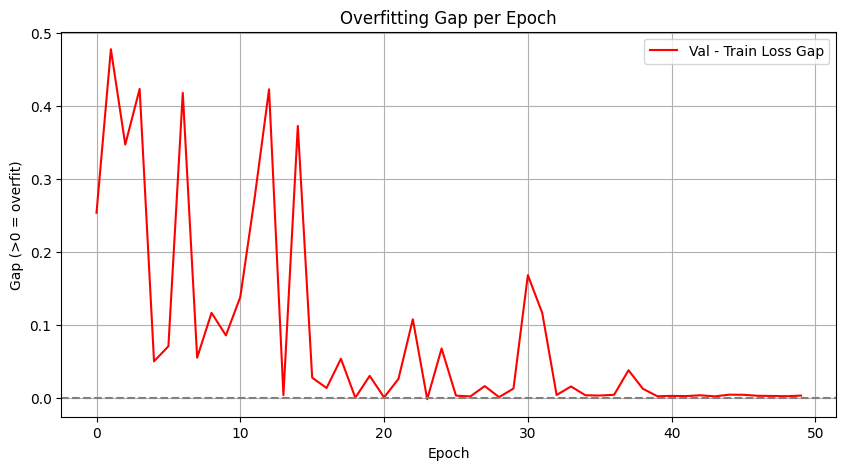

In [26]:
# ==== Cell 2: Overfitting Gap ====
import numpy as np

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])

gap = val_loss - train_loss

plt.figure(figsize=(10,5))
plt.plot(gap, label='Val - Train Loss Gap', color='red')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Overfitting Gap per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Gap (>0 = overfit)")
plt.grid(True)
plt.legend()
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


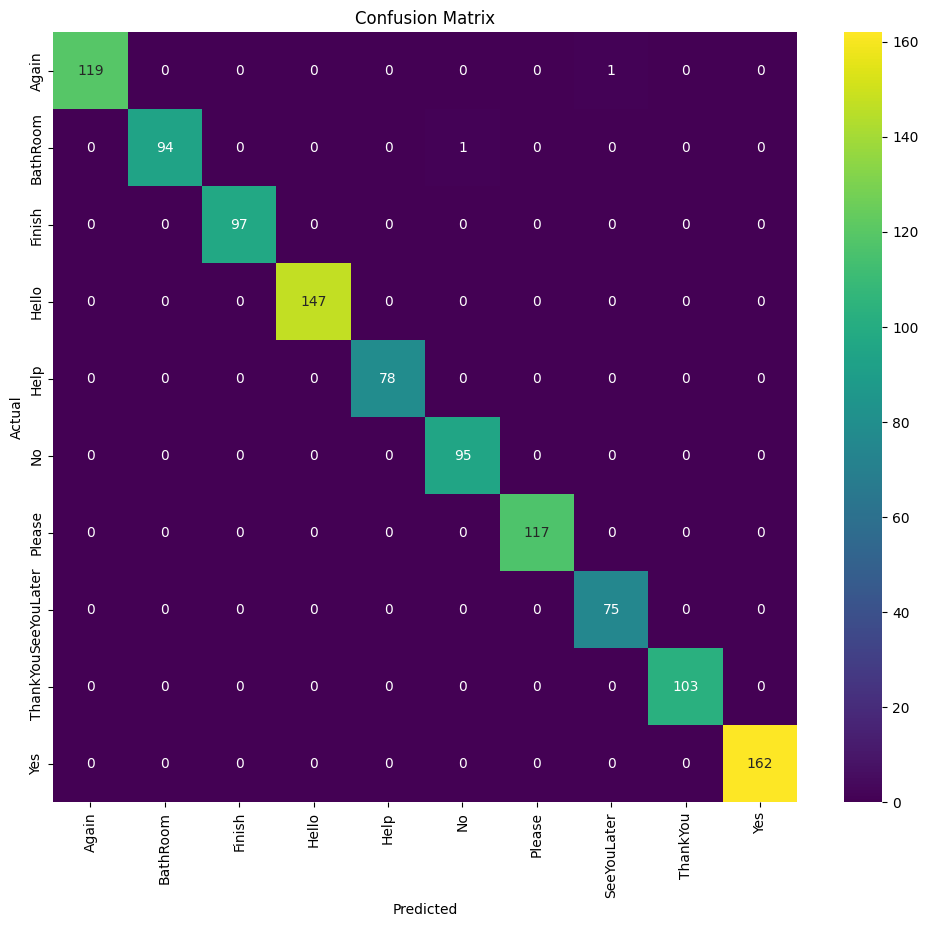

In [28]:
# ==== Cell 4: Confusion Matrix ====
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

true_labels = np.argmax(y_val, axis=1)
pred_labels = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=actions, yticklabels=actions)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
